Extracting parameters from C:\Users\mhfar\OneDrive\Desktop\Depo\Code\Neural Engineering\ELE568-Depo\Data\Test3\NS_feltTCRE_BrainAmp_5-2-2025.vhdr...
Setting channel info structure...
Reading 0 ... 1499719  =      0.000 ...  1499.719 secs...
Used Annotations descriptions: ['Comment/EO', 'Comment/ec', 'Comment/eo', 'Comment/re-gelled running VEP again', 'New Segment/', 'Stimulus/S  7']

🔄 Found 229 events with 6 unique event types
Event dictionary: {'Comment/EO': 10001, 'Comment/ec': 10002, 'Comment/eo': 10003, 'Comment/re-gelled running VEP again': 10004, 'New Segment/': 99999, 'Stimulus/S  7': 7}

✅ EEG Info:
- Channels: 15
- Channel names: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
- Duration: 1499.72 sec
- Sampling Rate: 1000.0 Hz

📏 Global Signal STD (µV): 1176.3725

========== CONTINUOUS EEG ANALYSIS ==========
Effective window size : 4.000 (s)

⚡ Band Power (total across all channels):
- Delta (0.5–4 Hz): 0.00000380
- Theta (4–8 Hz): 0.000000

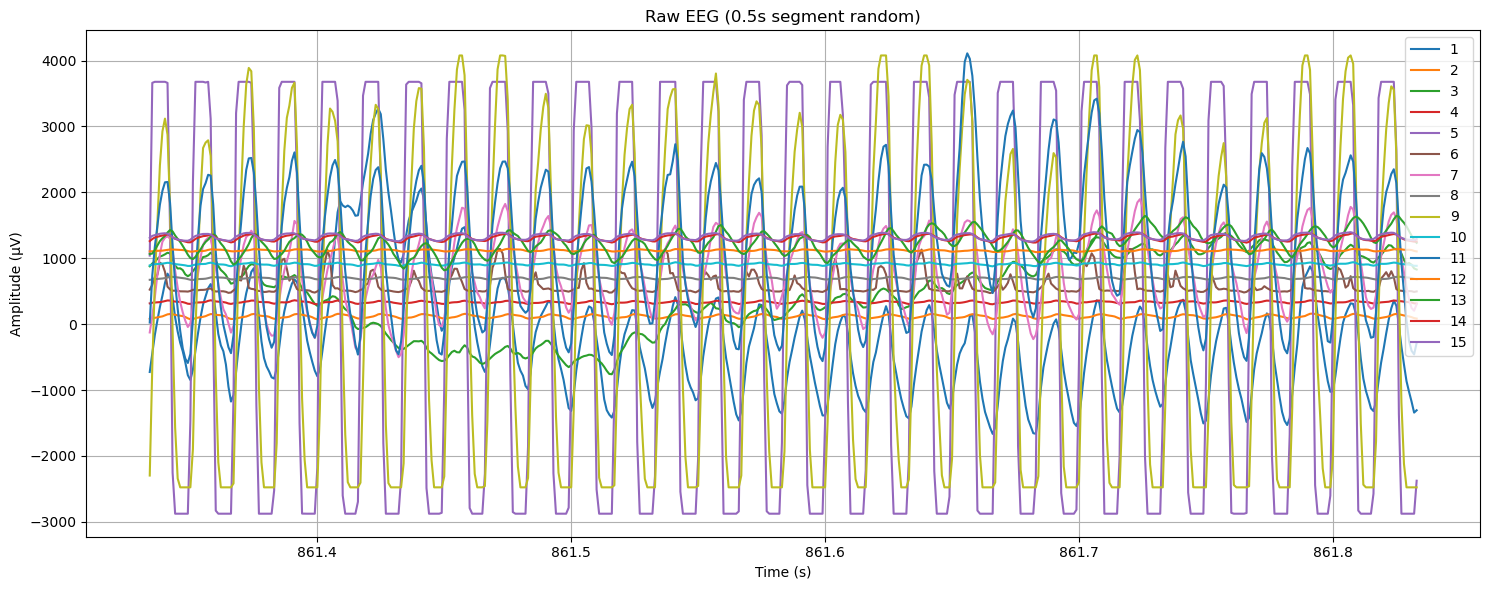

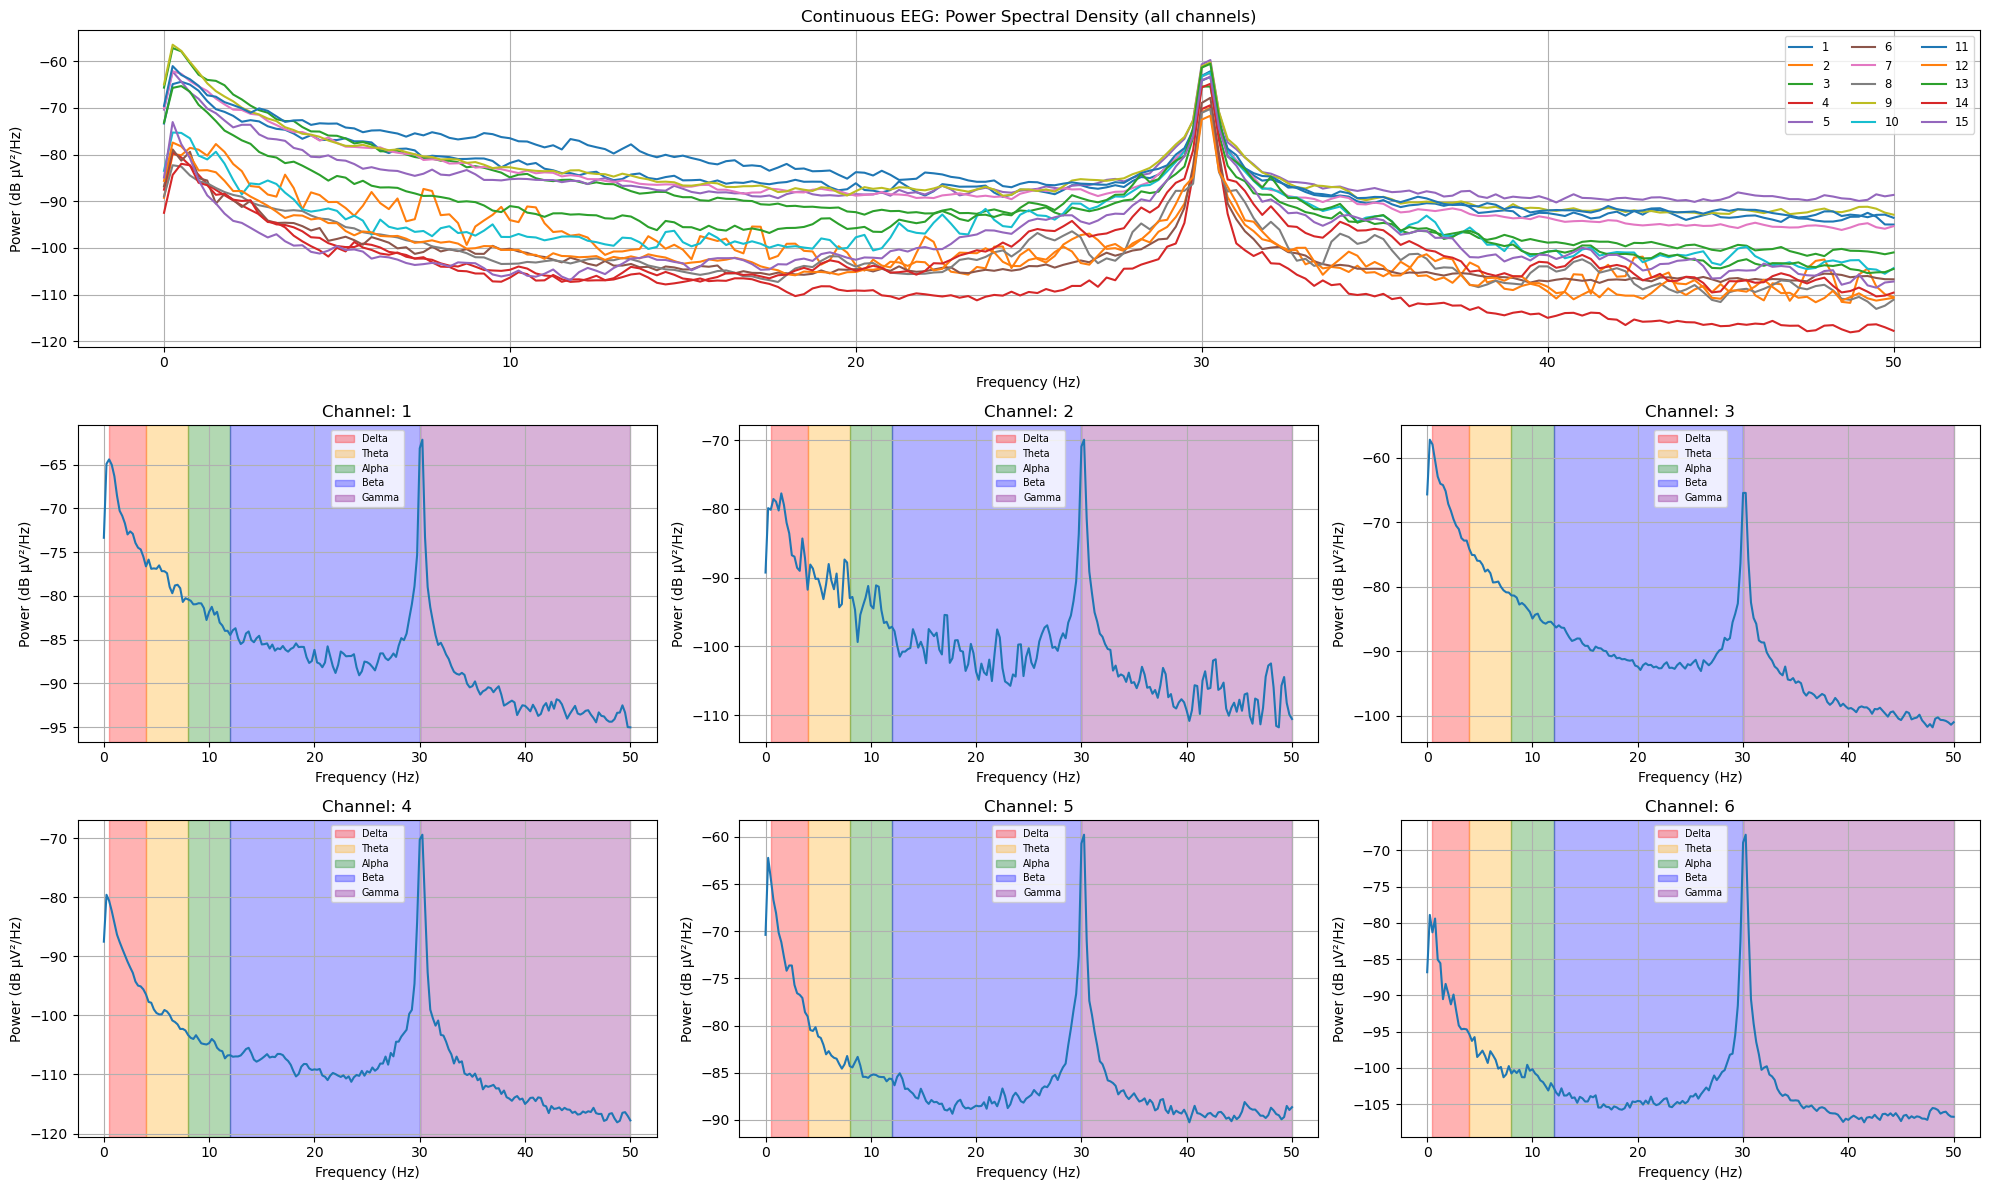

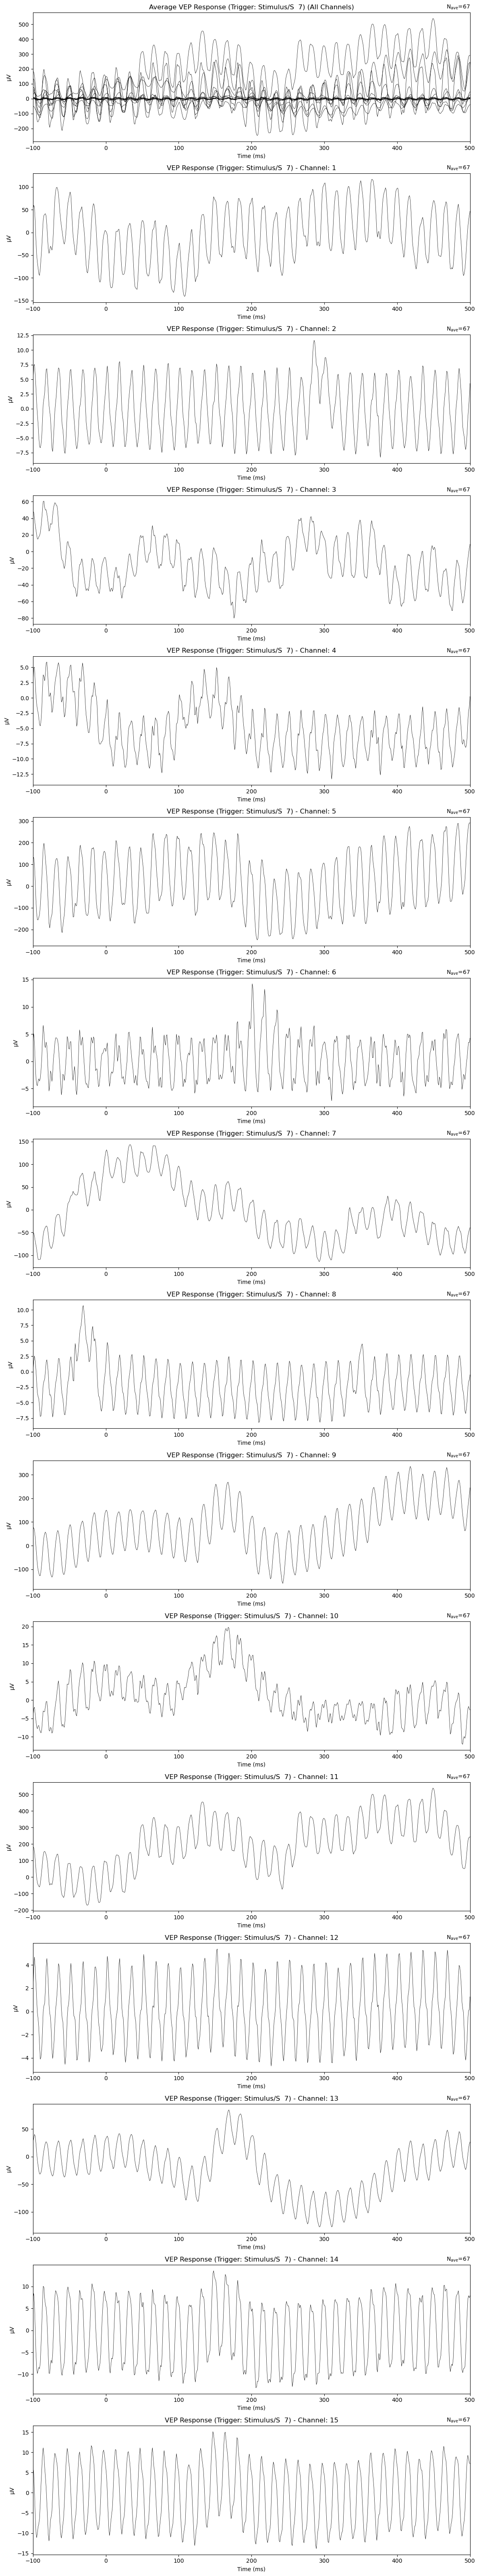

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps
from matplotlib.gridspec import GridSpec
import os
import pandas as pd
import scipy.signal  # Added for Hilbert transform

# -----------------------------
# File Setup and Loading
# -----------------------------
base_dir = r"C:\Users\mhfar\OneDrive\Desktop\Depo\Code\Neural Engineering\ELE568-Depo\Data\Test3"
base_fname = "NS_feltTCRE_BrainAmp_5-2-2025"

# Load main EEG file
vhdr_file = os.path.join(base_dir, f"{base_fname}.vhdr")
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

# Find and load trigger events from marker file
events_from_annot, event_dict = mne.events_from_annotations(raw)
print(f"\n🔄 Found {len(events_from_annot)} events with {len(event_dict)} unique event types")
print(f"Event dictionary: {event_dict}")

# -----------------------------
# Basic EEG Info
# -----------------------------
n_channels = len(raw.ch_names)
duration_sec = raw.times[-1]
sfreq = raw.info['sfreq']
print(f"\n✅ EEG Info:")
print(f"- Channels: {n_channels}")
print(f"- Channel names: {raw.ch_names}")
print(f"- Duration: {duration_sec:.2f} sec")
print(f"- Sampling Rate: {sfreq} Hz")

# -----------------------------
# Global Amplitude / Noise
# -----------------------------
data = raw.get_data()
std = data.std()
print(f"\n📏 Global Signal STD (µV): {std * 1e6:.4f}")

# -----------------------------
# PSD Computation and Visualization
# -----------------------------
def compute_and_visualize_psd(raw_data, title_prefix="", fmax=50):
    """Compute PSD and create visualization for the input data"""
    psd = raw_data.compute_psd(fmax=fmax, n_fft=int(sfreq * 4))  # 4-second window for better frequency resolution
    psds, freqs = psd.get_data(return_freqs=True)
    psds_db = 10 * np.log10(psds)
    
    # Compute band powers
    band_powers, band_relative_powers = compute_band_powers(psds, freqs)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 3, figure=fig)
    
    # 1. Main PSD plot (all channels)
    ax1 = fig.add_subplot(gs[0, :])
    for i, ch in enumerate(raw_data.ch_names):
        ax1.plot(freqs, psds_db[i], label=ch)
    ax1.set_title(f"{title_prefix}Power Spectral Density (all channels)")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Power (dB µV²/Hz)")
    ax1.legend(fontsize='small', ncol=3)
    ax1.grid(True)
    
    # 2. Individual channel PSD plots
    ch_count = len(raw_data.ch_names)
    grid_cols = min(3, ch_count)
    grid_rows = (ch_count + grid_cols - 1) // grid_cols
    
    for i, ch in enumerate(raw_data.ch_names):
        row = 1 + (i // grid_cols)
        col = i % grid_cols
        if row < 3 and col < 3:  # Ensure we don't exceed grid size
            ax = fig.add_subplot(gs[row, col])
            ax.plot(freqs, psds_db[i])
            ax.set_title(f"Channel: {ch}")
            ax.set_xlabel("Frequency (Hz)")
            ax.set_ylabel("Power (dB µV²/Hz)")
            ax.axvspan(0.5, 4, color='red', alpha=0.3, label='Delta')
            ax.axvspan(4, 8, color='orange', alpha=0.3, label='Theta')
            ax.axvspan(8, 12, color='green', alpha=0.3, label='Alpha')
            ax.axvspan(12, 30, color='blue', alpha=0.3, label='Beta')
            ax.axvspan(30, 50, color='purple', alpha=0.3, label='Gamma')
            ax.legend(fontsize='x-small')
            ax.grid(True)
    
    plt.tight_layout()
    return fig, band_powers, band_relative_powers, psds, freqs

# -----------------------------
# Band Power Estimation
# -----------------------------
def compute_band_powers(psds, freqs):
    """Compute absolute and relative power in standard frequency bands"""
    def bandpower(data, freqs, band):
        idx = np.logical_and(freqs >= band[0], freqs <= band[1])
        # For each channel, calculate band power using Simpson's rule
        powers = np.zeros(data.shape[0])
        for i in range(data.shape[0]):
            powers[i] = simps(data[i, idx], freqs[idx])
        # Return the sum across all channels
        return float(np.sum(powers))  # Convert to float to avoid numpy formatting issues
    
    bands = {
        'Delta (0.5–4 Hz)': (0.5, 4),
        'Theta (4–8 Hz)': (4, 8),
        'Alpha (8–12 Hz)': (8, 12),
        'Beta (12–30 Hz)': (12, 30),
        'Gamma (30–50 Hz)': (30, 50)
    }
    
    # Calculate absolute power for each band
    band_powers = {}
    for label, band_range in bands.items():
        band_powers[label] = bandpower(psds, freqs, band_range)
    
    # Calculate total power across all bands
    total_power = sum(band_powers.values())
    
    # Calculate relative power (percentage of total)
    band_relative_powers = {}
    for label in bands.keys():
        band_relative_powers[label] = (band_powers[label] / total_power) * 100
    
    print(f"\n⚡ Band Power (total across all channels):")
    for label, power in band_powers.items():
        print(f"- {label}: {power:.8f}")
    
    print(f"\n📊 Relative Band Power (%):")
    for label, rel_power in band_relative_powers.items():
        print(f"- {label}: {rel_power:.2f}%")
    
    # SNR calculations
    snr_alpha_gamma = band_powers['Alpha (8–12 Hz)'] / band_powers['Gamma (30–50 Hz)']
    snr_alpha_beta = band_powers['Alpha (8–12 Hz)'] / band_powers['Beta (12–30 Hz)']
    print(f"\n📶 SNR Metrics:")
    print(f"- Alpha/Gamma SNR: {snr_alpha_gamma:.2f}")
    print(f"- Alpha/Beta SNR: {snr_alpha_beta:.2f}")
    
    return band_powers, band_relative_powers

# -----------------------------
# Plot Raw Data Segment
# -----------------------------
def plot_raw_segment(raw_data, duration=0.5, random=True, start_time=None):
    """Plot a segment of raw EEG data"""
    ch_count = len(raw_data.ch_names)
    data, times = raw_data[:ch_count, :]
    win = int(sfreq * duration)
    
    if random:
        start = np.random.randint(0, data.shape[1] - win)
    else:
        start = int(start_time * sfreq) if start_time is not None else 0
    
    seg = data[:, start:start+win]
    seg_time = times[start:start+win]
    
    offset = 100e-6  # Offset for stacking channels
    
    plt.figure(figsize=(15, 6))
    for i in range(ch_count):
        plt.plot(seg_time, seg[i] * 1e6 + i * offset * 1e6, label=raw_data.ch_names[i])
    
    plt.title(f"Raw EEG ({duration}s segment {'random' if random else f'at {start_time}s'})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    
    return plt.gcf()

# -----------------------------
# Epoch Data with Artifact Rejection
# -----------------------------
def create_clean_epochs(raw, events, event_id, tmin=-0.2, tmax=0.5, reject_threshold_mv=5):
    """Create epochs from raw data and reject artifacts above threshold"""
    
    # Set rejection threshold (converting from mV to V)
    reject_criteria = dict(eeg=reject_threshold_mv * 1e-3)  # 5 mV converted to V
    
    # Create epochs with rejection
    epochs = mne.Epochs(raw, events, event_id, tmin=tmin, tmax=tmax,
                        baseline=(tmin, 0), reject=reject_criteria,
                        preload=True, verbose=True)
    
    # Get information about dropped epochs
    drop_log = epochs.drop_log
    total_epochs = len(events)
    kept_epochs = len(epochs)
    dropped_epochs = total_epochs - kept_epochs
    drop_percent = (dropped_epochs / total_epochs) * 100 if total_epochs > 0 else 0
    
    print(f"\n🧹 Artifact Rejection:")
    print(f"- Total epochs: {total_epochs}")
    print(f"- Kept epochs: {kept_epochs}")
    print(f"- Rejected epochs: {dropped_epochs} ({drop_percent:.1f}%)")
    
    # Identify which channels had the most artifacts
    if dropped_epochs > 0:
        channel_drops = {}
        for ch in raw.ch_names:
            channel_drops[ch] = 0
        
        for log in drop_log:
            if log and len(log) > 0:
                for reason in log:
                    if reason != 'eeg' and reason in raw.ch_names:
                        channel_drops[reason] = channel_drops.get(reason, 0) + 1
        
        print("- Rejection count by channel:")
        for ch, count in channel_drops.items():
            if count > 0:
                print(f"  * {ch}: {count} epochs")
    
    return epochs

# -----------------------------
# Compute and Visualize Evoked Response
# -----------------------------
def process_vep_response(epochs, title="Visual Evoked Potential"):
    """Compute average evoked response and visualize it"""
    # Calculate evoked response (average across epochs)
    evoked = epochs.average()
    
    # Create figure for visualization
    ch_count = len(epochs.ch_names)
    fig, axes = plt.subplots(ch_count + 1, 1, figsize=(12, 4 * (ch_count + 1)))
    
    # Handle single channel case
    if ch_count == 1:
        axes = [axes]
    
    # Plot the average across all channels
    evoked.plot(picks='all', axes=axes[0], show=False, time_unit='ms')
    axes[0].set_title(f"Average {title} (All Channels)")
    
    # Plot individual channels
    for i, ch in enumerate(epochs.ch_names):
        if i < len(axes) - 1:  # Make sure we don't exceed array bounds
            evoked.plot(picks=[ch], axes=axes[i+1], show=False, time_unit='ms')
            axes[i+1].set_title(f"{title} - Channel: {ch}")
    
    plt.tight_layout()
    return fig, evoked

# -----------------------------
# Alpha Wave Analysis
# -----------------------------
def analyze_alpha_waves(raw):
    """Analyze alpha wave characteristics in the data"""
    # Filter data to alpha band (8-12 Hz)
    raw_alpha = raw.copy().filter(8, 12)
    
    # Get data
    alpha_data = raw_alpha.get_data() * 1e6  # convert to µV
    
    # Calculate alpha amplitude envelope using Hilbert transform
    alpha_envelope = np.abs(scipy.signal.hilbert(alpha_data, axis=1))
    
    # Calculate metrics
    alpha_mean = np.mean(alpha_envelope, axis=1)
    alpha_std = np.std(alpha_envelope, axis=1)
    alpha_max = np.max(alpha_envelope, axis=1)
    
    # Create visualization
    ch_count = len(raw.ch_names)
    fig, axes = plt.subplots(ch_count, 1, figsize=(15, 3 * ch_count))
    
    # Handle single channel case
    if ch_count == 1:
        axes = [axes]
    
    for i, ch in enumerate(raw.ch_names):
        # Plot 10 seconds of alpha signal and its envelope
        t_start = int(raw.times.shape[0] * 0.3)  # Start at 30% into recording
        segment_len = min(int(10 * sfreq), len(raw.times) - t_start)  # Handle case where recording is short
        t_end = t_start + segment_len
        
        t_plot = raw.times[t_start:t_end]
        axes[i].plot(t_plot, alpha_data[i, t_start:t_end], 'b', label='Alpha Filtered')
        axes[i].plot(t_plot, alpha_envelope[i, t_start:t_end], 'r', label='Envelope')
        axes[i].set_title(f"Alpha Activity - {ch} (Mean: {alpha_mean[i]:.2f} µV, Max: {alpha_max[i]:.2f} µV)")
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Amplitude (µV)")
        axes[i].legend()
        axes[i].grid(True)
    
    plt.tight_layout()
    
    # Create alpha metrics table
    metrics_df = pd.DataFrame({
        'Channel': raw.ch_names,
        'Mean Amplitude (µV)': alpha_mean,
        'Max Amplitude (µV)': alpha_max,
        'Std Dev (µV)': alpha_std,
    })
    
    print("\n🧠 Alpha Wave Metrics:")
    print(metrics_df.to_string(index=False))
    
    return fig, metrics_df

# -----------------------------
# MAIN ANALYSIS PIPELINE
# -----------------------------

try:
    # 1. Run continuous data analysis
    print("\n========== CONTINUOUS EEG ANALYSIS ==========")
    # Plot a random raw segment
    raw_fig = plot_raw_segment(raw)

    # Compute PSD and band powers for continuous data
    psd_fig, band_powers, band_rel_powers, psds_data, freqs_data = compute_and_visualize_psd(raw, "Continuous EEG: ")

    # 2. Process VEP epochs with artifact rejection
    print("\n========== VEP ANALYSIS WITH ARTIFACT REJECTION ==========")

    # Find stimulus triggers (adjust based on your actual event markers)
    trigger_keys = [key for key in event_dict.keys() if key.startswith('S')]
    if trigger_keys:
        # If you have specific trigger you want to use, select it here
        selected_trigger = trigger_keys[0]  # Using the first trigger type
        trigger_id = {selected_trigger: event_dict[selected_trigger]}
        
        print(f"\n🔍 Processing epochs for trigger: {selected_trigger}")
        
        # Create epochs with artifact rejection
        vep_epochs = create_clean_epochs(raw, events_from_annot, trigger_id, 
                                       tmin=-0.1, tmax=0.5, reject_threshold_mv=5)
        
        if len(vep_epochs) > 0:
            # Calculate and plot evoked response
            evoked_fig, evoked_data = process_vep_response(vep_epochs, 
                                                        title=f"VEP Response (Trigger: {selected_trigger})")
            
            # Compute PSD for the epochs
            epochs_psd_fig, epochs_powers, epochs_rel_powers, _, _ = compute_and_visualize_psd(
                vep_epochs, title_prefix="Epoched Data: "
            )
            
            # Compare the signal quality between continuous and epoched data
            print("\n📊 Signal Quality Comparison (Continuous vs. Clean Epochs):")
            for band in band_powers.keys():
                cont_power = band_powers[band]
                epoch_power = epochs_powers[band]
                rel_change = ((epoch_power - cont_power) / cont_power) * 100
                print(f"- {band}: {rel_change:.2f}% change after artifact rejection")
        else:
            print("⚠️ No clean epochs remained after artifact rejection.")
    else:
        print("⚠️ No suitable triggers found in the data.")

    # 3. Alpha wave analysis
    print("\n========== ALPHA WAVE ANALYSIS ==========")
    alpha_fig, alpha_metrics = analyze_alpha_waves(raw)

    # 4. Save all figures
    figures_to_save = {
        "raw_segment": raw_fig,
        "continuous_psd": psd_fig,
        "alpha_analysis": alpha_fig
    }

    if 'vep_epochs' in locals() and len(vep_epochs) > 0:
        figures_to_save.update({
            "vep_evoked": evoked_fig,
            "epochs_psd": epochs_psd_fig
        })

    # Save figures
    for name, fig in figures_to_save.items():
        fig.savefig(os.path.join(base_dir, f"{base_fname}_{name}.png"), dpi=300)

    # Show all figures
    plt.show()
    
except Exception as e:
    import traceback
    print(f"Error occurred: {e}")
    print(traceback.format_exc())